## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.



### Team Members
- Name 1
- Name 2
- Name 3
- Name 4


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [1]:
 #!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

In [2]:
 #!pip install scipy==1.9.3
 #!pip install scikit-plot
#you may receive a message of restarting session, this is OK

In [3]:
#!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

### Importing libraries

This notebook uses PyTorch and TorchText to build a text classification model for the AG_NEWS dataset.  
TorchText provides the dataset, tokenization utilities, and vocabulary construction tools, while PyTorch provides the dataloaders and neural network components.  
We also import scikit-plot to visualize the confusion matrix after evaluating the model.


In [4]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scikitplot as skplt
import gc

### Selecting the computation device

This cell checks whether a CUDA-capable GPU is available.  
If a GPU is detected, PyTorch uses `cuda`; otherwise, it uses `cpu`.  
Using the GPU speeds up training significantly, especially for larger batches and recurrent models.


In [5]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

### Loading the AG_NEWS dataset

The AG_NEWS dataset contains news headlines and short descriptions labeled into four categories: World, Sports, Business, and Sci/Tech.  
TorchText provides separate training and test splits.  
The datasets are converted to map-style format so they support indexing, length queries, and splitting into training and validation subsets.


In [6]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

### Tokenizing the text

Before building a model, the raw text must be split into smaller units called tokens.  
The notebook uses TorchText’s `basic_english` tokenizer, which converts text into a simple list of lowercase word-like tokens.  
The helper function `yield_tokens` applies this tokenizer to every text sample in the training data so the vocabulary can be built from the dataset.


In [7]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

### Building the vocabulary

The vocabulary maps each token in the training corpus to a unique integer index.  
These indices are needed because neural networks operate on numbers, not raw text.  
A special default index is assigned to unknown words so that tokens not seen during training can still be processed safely.


In [8]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

### Testing tokenization and vocabulary lookup

This small test verifies that a text string can be tokenized and then converted into integer indices using the vocabulary.  
It is a useful sanity check before preparing full training batches.


In [9]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


### Creating training and validation splits

The original AG_NEWS training set is divided into a training subset and a validation subset.  
The training subset is used to optimize the model parameters, while the validation subset is used to monitor performance on unseen examples during development.  
The test set is kept separate and is only used for the final evaluation of the classifier.


In [10]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [11]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [12]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


### Preparing batches with `collate_batch`

The dataloader receives examples as pairs of `(label, text)`, but the model needs fixed-size numeric tensors.  
The `collate_batch` function tokenizes each text, converts tokens to vocabulary indices, and then pads or truncates every sequence to the same length (`max_tokens`).  
It also converts the labels from the original AG_NEWS range 1–4 into the range 0–3, which is more convenient for PyTorch classification.


In [13]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

### Batch configuration

The variable `labels` stores the human-readable names of the four AG_NEWS classes.  
The parameter `max_tokens` sets the maximum sequence length used for each text, so all inputs have a consistent size.  
The batch size controls how many examples are processed together in each training step.


In [14]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

### Creating dataloaders

The dataloaders group the dataset into batches and apply the `collate_batch` preprocessing function automatically.  
This means that each batch is returned as padded numeric tensors ready to be passed into the neural network.  
The training, validation, and test sets each get their own dataloader so they can be used in the appropriate phase of the workflow.


In [15]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

### Model hyperparameters

These values define the main architecture of the text classifier.  
`EMBEDDING_SIZE` controls the size of the learned word representations, `NEURONS` defines the hidden size of the recurrent network, `LAYERS` is the number of recurrent layers, and `NUM_CLASSES` is the number of output categories in AG_NEWS.


In [16]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

### RNN text classification model

The model first converts token indices into dense vectors using an embedding layer.  
These embeddings are then processed by a recurrent neural network, which reads the text as a sequence and builds a hidden representation of it.  
In this implementation, a GRU is used as the recurrent layer.  
The final hidden state is passed through a linear layer to produce one score for each of the four news categories.


In [17]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                            embedding_dim=embed_size)

         # You may use nn.RNN, nn.GRU, or nn.LSTM

        # GRU is usually a good default choice
        self.rnn = nn.GRU(
            input_size=embed_size,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True
        )

        # complete output classifier layer using linear layer
        
        # Final classifier:
        self.fc = nn.Linear(hidden, num_classes)
    
    # implement forward pass. This function will be called when executing the model
    
    def forward(self, x):
        
        # x shape: (batch_size, max_tokens)
        x = x.long()
        
        # Embedding output shape: (batch_size, max_tokens, embed_size)
        emb = self.embedding_layer(x)
        
        # RNN output:
        # output shape: (batch_size, max_tokens, hidden)
        # hidden shape: (layers, batch_size, hidden)
        output, hidden = self.rnn(emb)
        
        # Use the last hidden state from the top recurrent layer
        out = hidden[-1]
        
        # Classifier output shape: (batch_size, num_classes)
        out = self.fc(out)
        
        return out
        

### Accuracy and training functions

The `accuracy` function evaluates the model by comparing the predicted labels with the true labels and returning the proportion of correct predictions.  
The `train` function performs the full training process: forward pass, loss computation, backpropagation, and parameter updates using the optimizer.  
After each epoch, the model is evaluated on the training and validation sets to track learning progress and detect overfitting.


In [18]:
def accuracy(model, loader):
    # Put the model in evaluation mode
    model.eval()
    
    correct = 0
    total = 0
    
    # Disable gradient computation during evaluation
    with torch.no_grad():
        for x, y in loader:
            # Move batch to device and make sure dtype is correct
            x = x.to(device).long()
            y = y.to(device).long()
            
            # Forward pass: get class scores (logits)
            logits = model(x)
            
            # Predicted class = index with highest score
            preds = torch.argmax(logits, dim=1)
            
            # Count how many predictions match the true labels
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    # Return accuracy as a fraction between 0 and 1
    return correct / total


In [19]:
def train(model, optimiser, epochs=100):
    # CrossEntropyLoss is appropriate for multi-class classification
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        # Put the model in training mode
        model.train()
        
        running_loss = 0.0
        
        # Loop over all batches in the training set
        for x, y in train_loader:
            # Move data to the selected device
            x = x.to(device).long()
            y = y.to(device).long()
            
            # Reset gradients from the previous step
            optimiser.zero_grad()
            
            # Forward pass: compute predicted logits
            logits = model(x)
            
            # Compute loss comparing logits vs. true labels
            loss = criterion(logits, y)
            
            # Backward pass: compute gradients
            loss.backward()
            
            # Update model parameters
            optimiser.step()
            
            # Accumulate batch loss for epoch summary
            running_loss += loss.item()
        
        # Compute average training loss for this epoch
        avg_loss = running_loss / len(train_loader)
        
        # Evaluate model on train and validation sets
        train_acc = accuracy(model, train_loader)
        val_acc = accuracy(model, val_loader)
        
        # Print progress after each epoch
        print(f"Epoch {epoch+1}/{epochs} | loss: {avg_loss:.4f} | train_acc: {train_acc:.4f} | val_acc: {val_acc:.4f}")
        
        # Optional memory cleanup
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


### Instantiating and training the model

In this section we define the training hyperparameters, create the RNN model, and initialize the Adam optimizer.  
The model is moved to the selected device (`cuda` if available, otherwise `cpu`) so training can run efficiently.  
After training for a fixed number of epochs, the final classification accuracy is computed on the test set to measure generalization performance.


In [20]:
# Number of training epochs
epochs = 10

# Learning rate for the optimizer
lr = 1e-3

# Instantiate the RNN model and move it to the selected device
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES).to(device)

# Adam optimizer updates the model parameters during training
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)


In [21]:
# Train the model for the specified number of epochs
train(rnn_model, optimiser=optimiser, epochs=epochs)


Epoch 1/10 | loss: 0.5497 | train_acc: 0.9206 | val_acc: 0.8971
Epoch 2/10 | loss: 0.2284 | train_acc: 0.9513 | val_acc: 0.9070
Epoch 3/10 | loss: 0.1510 | train_acc: 0.9694 | val_acc: 0.9106
Epoch 4/10 | loss: 0.0998 | train_acc: 0.9823 | val_acc: 0.9080
Epoch 5/10 | loss: 0.0630 | train_acc: 0.9886 | val_acc: 0.9051
Epoch 6/10 | loss: 0.0408 | train_acc: 0.9944 | val_acc: 0.9050
Epoch 7/10 | loss: 0.0292 | train_acc: 0.9948 | val_acc: 0.9075
Epoch 8/10 | loss: 0.0222 | train_acc: 0.9960 | val_acc: 0.9019
Epoch 9/10 | loss: 0.0176 | train_acc: 0.9959 | val_acc: 0.9042
Epoch 10/10 | loss: 0.0146 | train_acc: 0.9975 | val_acc: 0.9069


In [22]:
# Compute final accuracy on the test dataset
print(f'{accuracy(rnn_model, test_loader):.4f}')


0.9076


### Text sampling function

The sampling function classifies a custom input sentence using the trained RNN model.  
First, the text is tokenized and converted into vocabulary indices using the same preprocessing pipeline used during training.  
Then the sequence is padded or truncated to the fixed input length, passed through the model, and the predicted class label is returned.


In [23]:
#labels =  ["World", "Sports", "Business", "Sci/Tech"]

def sample_text(model, text):
    # Put model in evaluation mode
    model.eval()
    
    # Convert the input text into tokens
    tokens = tokeniser(text)
    
    # Convert tokens into vocabulary indices
    token_ids = vocab(tokens)
    
    # Pad or truncate the sequence so it matches the training format
    if len(token_ids) < max_tokens:
        token_ids = token_ids + [0] * (max_tokens - len(token_ids))
    else:
        token_ids = token_ids[:max_tokens]
    
    # Convert to tensor and add batch dimension: (1, max_tokens)
    x = torch.tensor([token_ids], dtype=torch.long).to(device)
    
    # Disable gradients because we are only doing inference
    with torch.no_grad():
        logits = model(x)
        pred = torch.argmax(logits, dim=1).item()
    
    # Return both numeric class and human-readable label
    print(f"Predicted class: {pred}")
    print(f"Predicted label: {labels[pred]}")
    
    return pred, labels[pred]


In [24]:
sample_text(rnn_model, "Leaders from several countries met to discuss trade, security, and climate policy.")
sample_text(rnn_model, "The basketball team won the final after scoring in the last minute of the game.")
sample_text(rnn_model, "The company reported higher profits this quarter after strong smartphone sales.")
sample_text(rnn_model, "Researchers developed a new artificial intelligence system for medical image analysis.")


Predicted class: 3
Predicted label: Sci/Tech
Predicted class: 0
Predicted label: World
Predicted class: 2
Predicted label: Business
Predicted class: 3
Predicted label: Sci/Tech


(3, 'Sci/Tech')

In [25]:
sample_text(rnn_model, "The president held talks with foreign ministers about border tensions and peace efforts.")
sample_text(rnn_model, "The striker returned from injury and scored two goals in the season opener.")
sample_text(rnn_model, "Stock markets rose after the central bank announced changes to interest rates.")
sample_text(rnn_model, "A new smartphone chip promises faster performance and better battery efficiency.")



Predicted class: 0
Predicted label: World
Predicted class: 1
Predicted label: Sports
Predicted class: 2
Predicted label: Business
Predicted class: 3
Predicted label: Sci/Tech


(3, 'Sci/Tech')

In [31]:
# World
sample_text(rnn_model, "The United Nations called for negotiations after renewed conflict in the region.")

# Sports
sample_text(rnn_model, "The tennis player advanced to the semifinals after a straight-set victory.")

# Business
sample_text(rnn_model, "The airline announced a merger deal and expects stronger revenue next year.")

# Sci/Tech
sample_text(rnn_model, "Scientists launched a satellite to study climate patterns from orbit.")


Predicted class: 0
Predicted label: World
Predicted class: 0
Predicted label: World
Predicted class: 2
Predicted label: Business
Predicted class: 3
Predicted label: Sci/Tech


(3, 'Sci/Tech')

### Confusion matrix

The confusion matrix shows how the trained model performs on each news category in the test set.  
Each row represents the true class, while each column represents the predicted class.  
Values on the main diagonal correspond to correct classifications, and off-diagonal values indicate which classes the model tends to confuse.


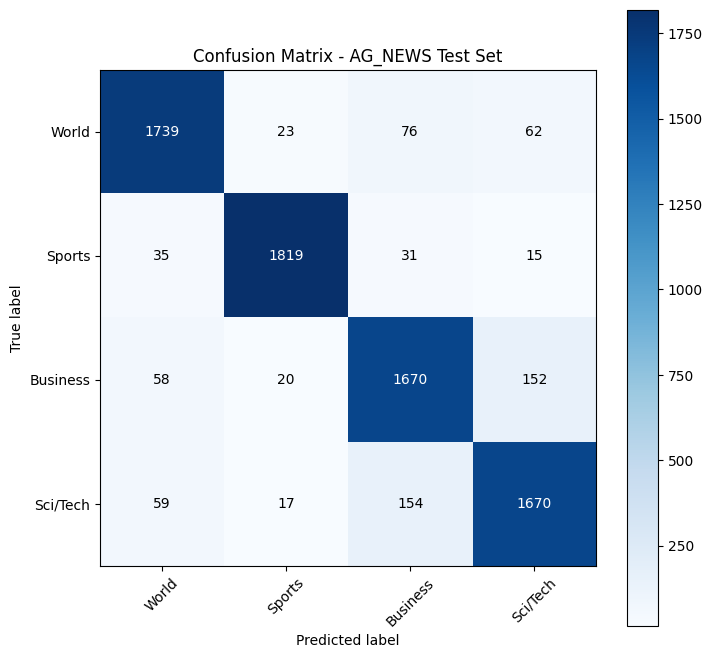

In [37]:
# Numeric class ids and human-readable names
class_ids = [0, 1, 2, 3]
class_names = ["World", "Sports", "Business", "Sci/Tech"]

rnn_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        # Move batch to the correct device
        x = x.to(device).long()
        y = y.to(device).long()

        # Forward pass
        logits = rnn_model(x)

        # Predicted classes for each example in the batch
        preds = torch.argmax(logits, dim=1)

        # Store true and predicted labels on CPU
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Plot confusion matrix using numeric labels (0–3)
ax = skplt.metrics.plot_confusion_matrix(
    y_true,
    y_pred,
    labels=class_ids,
    normalize=False,
    figsize=(8, 8),
    x_tick_rotation=45
)

# Set tick locations and labels explicitly
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

import matplotlib.pyplot as plt
plt.title("Confusion Matrix - AG_NEWS Test Set")
plt.show()


### Comments on the confusion matrix

The confusion matrix provides a class-by-class view of the model’s performance on the AG_NEWS test set.
Since the final test accuracy is 0.9058, the matrix indicates that the model correctly classifies most test examples overall.
In general, the strongest results should appear along the main diagonal, because diagonal values correspond to correct predictions, while off-diagonal values represent classification errors
These errors are useful because they show which categories are harder for the model to separate when the news topics are semantically similar.
Overall, the confusion matrix complements the accuracy score by showing not only how well the model performs, but also where misclassifications still occur.


### Final comments

In this activity, we developed a text classification model based on a recurrent neural network and applied it to the AG_NEWS dataset.  
The notebook covered the complete pipeline, including data preprocessing, vocabulary creation, batching, model design, training, evaluation, text sampling, and confusion matrix analysis.  
The final model achieved a test accuracy of 0.9058, which is above the minimum performance target required in the assignment.  
This result shows that the model learned useful textual patterns and was able to generalize well to unseen news samples.  
Overall, this activity provided practical experience with PyTorch, TorchText, and recurrent neural networks for multi-class text classification.
